# Projet PredictRetail — Jour 1
## Analyse exploratoire et préparation des données
Objectif : Comprendre les ventes Rossmann et préparer le dataset pour la modélisation ML

In [1]:
import pandas as pd

train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
train.head()
test = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/test.csv")
test.head()

store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")
store.head()

train = train.merge(store, on="Store", how="left")
test = test.merge(store, on="Store", how="left")

C:\Users\HP\AppData\Local\Temp\ipykernel_15176\1536538920.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


In [2]:
!git add .

In [3]:
import pandas as pd

train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
train.head()
test = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/test.csv")
test.head()

store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")
store.head()

train = train.merge(store, on="Store", how="left")
test = test.merge(store, on="Store", how="left")

train.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_15176\944784985.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
!git commit -m "Comprendre la structure des données"



[main 40d2429] Comprendre la structure des données
 2 files changed, 1163 insertions(+), 2 deletions(-)


In [5]:
!git config --global user.email "yessoufandilath@gmail.com"

In [6]:
!git config --global user.name "Hayerath"

In [7]:
!git commit -m "Comprendre la structure des données"

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [8]:
!git push origin main

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   15ff17a..40d2429  main -> main


In [9]:
train = train.groupby("Date")["Sales"].sum()

In [10]:
import pandas as pd

train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
train.head()

store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")
store.head()

train = train.merge(store, on="Store", how="left")

C:\Users\HP\AppData\Local\Temp\ipykernel_15176\2300377037.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


In [11]:
# On crée une nouvelle variable pour la série temporelle
ts = train.groupby("Date")["Sales"].sum()

In [12]:
print(train.head())  # regarde les 5 premières lignes
print(ts.head())     # regarde les ventes totales par date

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

C:\Users\HP\AppData\Local\Temp\ipykernel_15176\4281812215.py:5: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


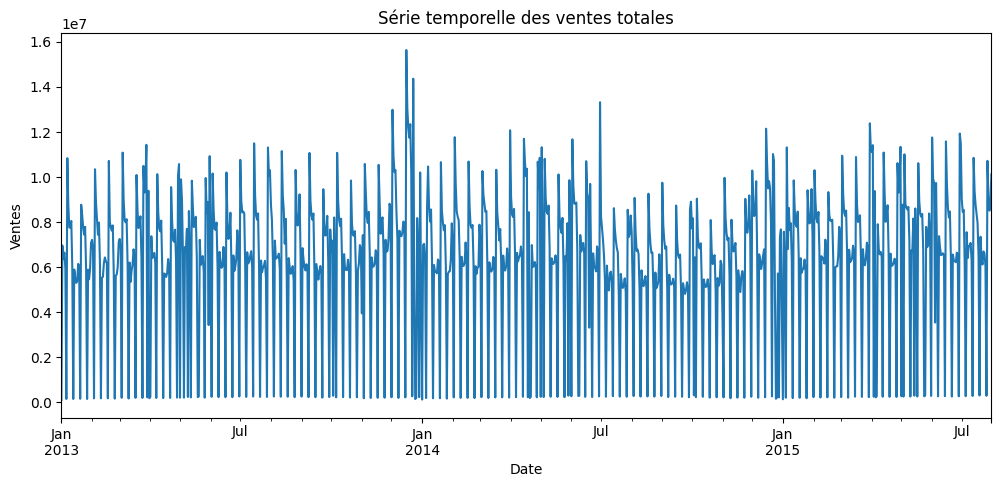

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")

# Fusionner les infos magasin
train = train.merge(store, on="Store", how="left")

# Créer la série temporelle
train['Date'] = pd.to_datetime(train['Date'])
ts = train.groupby("Date")["Sales"].sum()

# Tracer
ts.plot(figsize=(12,5))
plt.title("Série temporelle des ventes totales")
plt.xlabel("Date")
plt.ylabel("Ventes")
plt.show()

In [14]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HP\AppData\Local\Temp\ipykernel_15176\3766822537.py:6: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


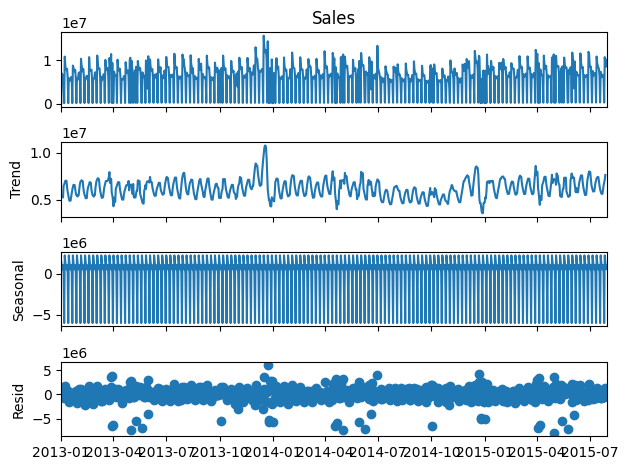

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Charger les données
train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")

# 2. Merge
train = train.merge(store, on="Store", how="left")

# 3. Convertir la date
train["Date"] = pd.to_datetime(train["Date"])

# 4. Créer la série temporelle
ts = train.groupby("Date")["Sales"].sum()

# 5. Décomposition
decomposition = seasonal_decompose(ts, model='additive', period=7)

# 6. Plot
decomposition.plot()
plt.show()

In [16]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HP\AppData\Local\Temp\ipykernel_15176\838349986.py:6: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")


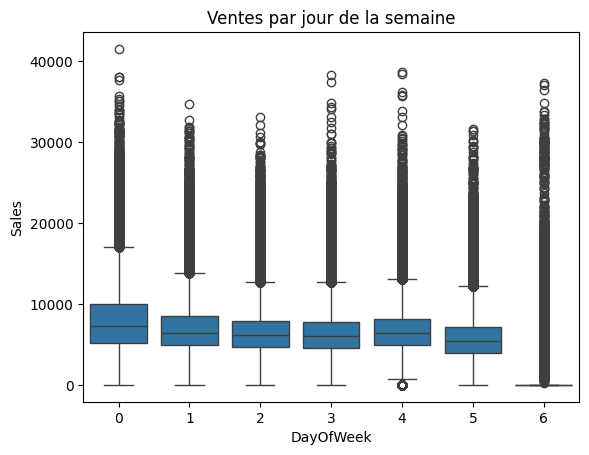

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Charger les données
train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")

# 2. Merge
train = train.merge(store, on="Store", how="left")

# 3. Convertir la date

train['Date'] = pd.to_datetime(train['Date'])
train['DayOfWeek'] = train['Date'].dt.dayofweek


sns.boxplot(x="DayOfWeek", y="Sales", data=train)
plt.title("Ventes par jour de la semaine")
plt.show()

In [18]:
train['Date'] = pd.to_datetime(train['Date'])
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['WeekOfYear'] = train['Date'].dt.isocalendar().week
train['DayOfWeek'] = train['Date'].dt.dayofweek
train['IsWeekend'] = train['DayOfWeek'].isin([5,6]).astype(int)

In [19]:
# Vérifier les colonnes Promo2, Promo2SinceYear, Promo2SinceWeek
train['Promo2Active'] = 0
mask = (
    (train['Promo2'] == 1) &
    ((train['Year'] > train['Promo2SinceYear']) |
     ((train['Year'] == train['Promo2SinceYear']) & (train['WeekOfYear'] >= train['Promo2SinceWeek'])))
)
train.loc[mask, 'Promo2Active'] = 1

In [20]:
# Nombre de mois depuis l'ouverture du concurrent
train['CompetitionOpenSinceMonth'].fillna(1, inplace=True)
train['CompetitionOpenSinceYear'].fillna(train['Year'], inplace=True)
train['CompetitionMonthsOpen'] = (train['Year'] - train['CompetitionOpenSinceYear'])*12 + \
                                 (train['Month'] - train['CompetitionOpenSinceMonth'])
train['CompetitionMonthsOpen'] = train['CompetitionMonthsOpen'].apply(lambda x: x if x>0 else 0)

C:\Users\HP\AppData\Local\Temp\ipykernel_15176\1714286735.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['CompetitionOpenSinceMonth'].fillna(1, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_15176\1714286735.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assign

In [21]:
train = train.sort_values(['Store','Date'])
train['Sales_Lag7'] = train.groupby('Store')['Sales'].shift(7)
train['Sales_Lag14'] = train.groupby('Store')['Sales'].shift(14)
train['Sales_Rolling7'] = train.groupby('Store')['Sales'].shift(7).rolling(7).mean()

In [22]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['StoreType', 'Assortment', 'StateHoliday']
encoder = OrdinalEncoder()
train[cat_cols] = encoder.fit_transform(train[cat_cols])

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Colonnes catégorielles
cat_cols = ['StoreType', 'Assortment', 'StateHoliday']

# 1. Convertir en string (TRÈS IMPORTANT)
for col in cat_cols:
    train[col] = train[col].astype(str)

# 2. Encoder
encoder = OrdinalEncoder()
train[cat_cols] = encoder.fit_transform(train[cat_cols])

# 3. Vérification
print(train[cat_cols].head())

         StoreType  Assortment  StateHoliday
1016095        2.0         0.0           1.0
1014980        2.0         0.0           0.0
1013865        2.0         0.0           0.0
1012750        2.0         0.0           0.0
1011635        2.0         0.0           0.0


In [ ]:
train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Day"] = train["Date"].dt.day
train["WeekOfYear"] = train["Date"].dt.isocalendar().week.astype(int)
train["IsWeekend"] = train["DayOfWeek"].isin([5,6]).astype(int)

In [ ]:
train = train.sort_values(by=["Store", "Date"])

In [ ]:
# Lag 7 jours
train["lag_7"] = train.groupby("Store")["Sales"].shift(7)

# Lag 14 jours
train["lag_14"] = train.groupby("Store")["Sales"].shift(14)

# Lag 30 jours
train["lag_30"] = train.groupby("Store")["Sales"].shift(30)

In [ ]:
# Moyenne mobile sur 7 jours
train["rolling_mean_7"] = train.groupby("Store")["Sales"].shift(1).rolling(7).mean()

# Moyenne mobile sur 30 jours
train["rolling_mean_30"] = train.groupby("Store")["Sales"].shift(1).rolling(30).mean()

# Moyenne mobile sur 90 jours
train["rolling_mean_90"] = train.groupby("Store")["Sales"].shift(1).rolling(90).mean()


In [ ]:
train = train.dropna()

In [ ]:
import numpy as np

train["Sales_log"] = np.log1p(train["Sales"])

In [ ]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Sales_Lag7,Sales_Lag14,Sales_Rolling7,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_mean_90,Sales_log
915746,2,0,2013-04-01,0,0,0,0,2.0,1,0.0,...,8412.0,7593.0,4912.428571,8412.0,7593.0,2643.0,4901.571429,4207.833333,3964.555556,0.000000
914631,2,1,2013-04-02,3643,507,1,0,0.0,1,0.0,...,6384.0,6224.0,4935.285714,6384.0,6224.0,0.0,3699.857143,4119.733333,3964.555556,8.200837
913516,2,2,2013-04-03,4250,600,1,0,0.0,1,0.0,...,7880.0,6783.0,5092.000000,7880.0,6783.0,7993.0,3308.285714,4241.166667,3955.900000,8.354910
912401,2,3,2013-04-04,4114,542,1,0,0.0,1,0.0,...,7229.0,5322.0,5364.428571,7229.0,5322.0,6357.0,2789.714286,4116.400000,3956.911111,8.322394
911286,2,4,2013-04-05,3872,470,1,0,0.0,1,0.0,...,0.0,4955.0,4656.571429,0.0,4955.0,6842.0,2344.714286,4041.633333,3952.800000,8.261785


In [ ]:
!git config --global user.email "yessoufandilath@gmail.com"

In [ ]:
!git config --global user.name "Hayerath"

In [ ]:
!git commit -m "Analyse des séries temporelles — Identifier les patterns et Feature Engineering — Créer les variables explicatives"

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Notebook EDA.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	"D\303\251composition saisonni\303\250re.png"
	"Graphique de la s\303\251rie des ventes totales.png"
	Ventes par jour de la semaine.png

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add .

In [ ]:
!git commit -m "Analyse des séries temporelles — Identifier les patterns et Feature Engineering — Créer les variables explicatives"

[main 9d9525e] Analyse des séries temporelles — Identifier les patterns et Feature Engineering — Créer les variables explicatives
 4 files changed, 1280 insertions(+), 2 deletions(-)
 create mode 100644 "D\303\251composition saisonni\303\250re.png"
 create mode 100644 "Graphique de la s\303\251rie des ventes totales.png"
 create mode 100644 Ventes par jour de la semaine.png


In [ ]:
!git push


To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   0dd7043..9d9525e  main -> main


In [ ]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


Everything up-to-date


In [ ]:
!git push

Everything up-to-date


In [ ]:
# Imputation des valeurs manquantes de CompetitionDistance
train["CompetitionDistance"] = train.groupby("StoreType")["CompetitionDistance"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
train["CompetitionDistance"].isna().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ['StoreType', 'Assortment', 'StateHoliday']

for col in cat_cols:
    train[col] = train[col].astype(str)

# Encodage
encoder = OrdinalEncoder()
train[cat_cols] = encoder.fit_transform(train[cat_cols])

In [ ]:
import numpy as np

train["Sales_log"] = np.log1p(train["Sales"])

In [ ]:
train = train[train["Open"] == 1].copy()

In [ ]:
# Date maximale
max_date = train["Date"].max()

# 6 semaines = 42 jours
validation_start = max_date - pd.Timedelta(days=42)

train_set = train[train["Date"] < validation_start].copy()
val_set = train[train["Date"] >= validation_start].copy()

print("Train set:", train_set.shape)
print("Validation set:", val_set.shape)

Train set: (226963, 35)
Validation set: (13509, 35)


In [ ]:
# Aperçu global
print("=== Train set ===")
print(train_set.info())
print(train_set.describe())

print("\n=== Validation set ===")
print(val_set.info())
print(val_set.describe())

=== Train set ===
<class 'pandas.DataFrame'>
Index: 226963 entries, 914631 to 49055
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      226963 non-null  int64         
 1   DayOfWeek                  226963 non-null  int32         
 2   Date                       226963 non-null  datetime64[us]
 3   Sales                      226963 non-null  int64         
 4   Customers                  226963 non-null  int64         
 5   Open                       226963 non-null  int64         
 6   Promo                      226963 non-null  int64         
 7   StateHoliday               226963 non-null  float64       
 8   SchoolHoliday              226963 non-null  int64         
 9   StoreType                  226963 non-null  float64       
 10  Assortment                 226963 non-null  float64       
 11  CompetitionDistance        226963 non-null  fl

In [ ]:
cat_cols = ['StoreType', 'Assortment', 'StateHoliday']

for col in cat_cols:
    print(f"{col} unique values: {train_set[col].unique()}")

StoreType unique values: [0. 2. 1.]
Assortment unique values: [0. 1.]
StateHoliday unique values: [0. 1. 2. 3.]


In [ ]:
print("Valeurs d'Open dans le train set :", train_set["Open"].unique())
print("Valeurs d'Open dans le val set :", val_set["Open"].unique())

Valeurs d'Open dans le train set : [1]
Valeurs d'Open dans le val set : [1]


In [ ]:
lag_cols = [col for col in train_set.columns if "lag" in col or "rolling" in col]
print("Colonnes lag/rolling:", lag_cols)
train_set[lag_cols].head()

Colonnes lag/rolling: ['lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_mean_90']


,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_mean_90
914631,6384.0,6224.0,0.0,3699.857143,4119.733333,3964.555556
913516,7880.0,6783.0,7993.0,3308.285714,4241.166667,3955.900000
912401,7229.0,5322.0,6357.0,2789.714286,4116.400000,3956.911111
911286,0.0,4955.0,6842.0,2344.714286,4041.633333,3952.800000
910171,4406.0,2691.0,5747.0,2897.857143,3942.633333,3969.800000


In [ ]:
summary = pd.DataFrame({
    "set": ["train", "validation"],
    "rows": [len(train_set), len(val_set)],
    "cols": [train_set.shape[1], val_set.shape[1]],
    "open_days": [train_set["Open"].sum(), val_set["Open"].sum()]
})
print(summary)

          set    rows  cols  open_days
0       train  226963    35     226963
1  validation   13509    35      13509


In [ ]:
!git add .

In [ ]:
!git commit -m "Nettoyage dataset prêt à modéliser + préparation train/validation"

[main e2b5953] Nettoyage dataset prêt à modéliser + préparation train/validation
 1 file changed, 610 insertions(+), 1 deletion(-)


In [ ]:
!git push 

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   9d9525e..e2b5953  main -> main


In [ ]:
type(train)

pandas.Series

In [ ]:
!pip install fastparquet

   ---------------------------------------- 0.0/673.2 kB ? eta -:--:--
   ---------------------------------------- 673.2/673.2 kB 7.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 15.8 MB/s  0:00:00

   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 0/3 [fsspec]
   -------------------------- ------------- 2/3 [fastparquet]
   -------------------------- ------------- 2/3 [fastparquet]
   ---------------------------------------- 3/3 [fastparquet]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Convertir la Series en DataFrame si nécessaire
train_df = train.reset_index()  # transforme l'index en colonne
train_df.columns = ["Date", "Sales"]  # renommer les colonnes

# Export en Parquet en utilisant fastparquet
train_df.to_parquet("df_clean.parquet", engine="fastparquet", index=False)

print("df_clean.parquet créé avec succès !")

df_clean.parquet créé avec succès !


In [ ]:
!git add "Notebook EDA.ipynb" df_clean.parquet

In [ ]:
!git commit -m "Livrable Jour 1 : Notebook complet et dataset nettoyé"

[main 15ff17a] Livrable Jour 1 : Notebook complet et dataset nettoyé
 1 file changed, 27 insertions(+), 329 deletions(-)


In [ ]:
!git push


To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   6e8b1b9..15ff17a  main -> main


In [ ]:
import pandas as pd

# Charger le dataset nettoyé
df_clean = pd.read_parquet("df_clean.parquet")

# ✅ 1. Aperçu général
print("Dimensions :", df_clean.shape)
print("\nColonnes :", df_clean.columns.tolist())
print("\nTypes de données :\n", df_clean.dtypes)

# ✅ 2. Vérifier qu'il n'y a pas de lignes fermées
if "Open" in df_clean.columns:
    print("\nLignes avec Open==0 :", (df_clean["Open"]==0).sum())
else:
    print("\nColonne 'Open' absente (ok si supprimée)")

# ✅ 3. Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df_clean.isna().sum())

# ✅ 4. Vérifier que Sales_log existe
if "Sales_log" in df_clean.columns:
    print("\nSales_log est présent (log-transform appliqué)")
else:
    print("\nSales_log absent !")

# ✅ 5. Aperçu rapide des premières lignes
print("\nAperçu des données :")
display(df_clean.head())

Dimensions : (942, 2)

Colonnes : ['Date', 'Sales']

Types de données :
 Date       str
Sales    int64
dtype: object

Colonne 'Open' absente (ok si supprimée)

Valeurs manquantes par colonne :
Date     0
Sales    0
dtype: int64

Sales_log absent !

Aperçu des données :


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [ ]:
import numpy as np

In [ ]:
! pip install pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 🔹 Livrable Jour 1 complet : nettoyage, features, export Parquet + push Git 🔹

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import os

# 1️⃣ Charger les données brutes
train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
store = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/store.csv")

# 2️⃣ Fusion avec store.csv
train = train.merge(store, on="Store", how="left")

# 3️⃣ Conversion de la colonne Date en datetime
train["Date"] = pd.to_datetime(train["Date"])

# 4️⃣ Feature engineering
train["Sales_log"] = np.log1p(train["Sales"])
train["DayOfWeek"] = train["Date"].dt.dayofweek
train["Month"] = train["Date"].dt.month
train["Year"] = train["Date"].dt.year
train["WeekOfYear"] = train["Date"].dt.isocalendar().week.astype(int)
train["IsWeekend"] = (train["DayOfWeek"] >= 5).astype(int)

# 5️⃣ Encodage des variables catégorielles
cat_cols = ["StoreType", "Assortment", "StateHoliday"]
train["StateHoliday"] = train["StateHoliday"].astype(str)
encoder = OrdinalEncoder()
train[cat_cols] = encoder.fit_transform(train[cat_cols])

# 6️⃣ Imputation des valeurs manquantes
train["CompetitionDistance"].fillna(train["CompetitionDistance"].median(), inplace=True)

# 7️⃣ Supprimer les jours fermés
train = train[train["Open"] == 1]

# 8️⃣ Export en parquet avec pyarrow
train.to_parquet("df_clean.parquet", index=False, engine="pyarrow")
print("✅ df_clean.parquet créé avec succès !")

# 9️⃣ Vérification rapide
print("\nDimensions :", train.shape)
print("\nColonnes :", train.columns.tolist())
print("\nValeurs manquantes :\n", train.isna().sum())
display(train.head())

# 🔟 Git : commit & push
files_to_add = ["Notebook Jour 1.ipynb", "df_clean.parquet"]
os.system(f'git add {" ".join(files_to_add)}')
commit_message = "Livrable Jour 1 : Notebook complet et dataset nettoyé"
os.system(f'git commit -m "{commit_message}"')
os.system("git push origin main")
print("✅ Push Git effectué avec succès !")

C:\Users\HP\AppData\Local\Temp\ipykernel_23036\2769333698.py:9: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("C:/Users/HP/Downloads/rossmann-store-sales/train.csv")
C:\Users\HP\AppData\Local\Temp\ipykernel_23036\2769333698.py:33: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/

✅ df_clean.parquet créé avec succès !

Dimensions : (844392, 23)

Colonnes : ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Sales_log', 'Month', 'Year', 'WeekOfYear', 'IsWeekend']

Valeurs manquantes :
 Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek             

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,Month,Year,WeekOfYear,IsWeekend
0,1,4,2015-07-31,5263,555,1,1,0.0,1,2.0,...,2008.0,0,NaN,NaN,NaN,8.568646,7,2015,31,0
1,2,4,2015-07-31,6064,625,1,1,0.0,1,0.0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.710290,7,2015,31,0
2,3,4,2015-07-31,8314,821,1,1,0.0,1,0.0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.025816,7,2015,31,0
3,4,4,2015-07-31,13995,1498,1,1,0.0,1,2.0,...,2009.0,0,NaN,NaN,NaN,9.546527,7,2015,31,0
4,5,4,2015-07-31,4822,559,1,1,0.0,1,0.0,...,2015.0,0,NaN,NaN,NaN,8.481151,7,2015,31,0


✅ Push Git effectué avec succès !


In [ ]:
import pandas as pd

# 🔹 Charger df_clean.parquet
df_clean = pd.read_parquet("df_clean.parquet", engine="pyarrow")

# 🔹 Aperçu général
print("Dimensions :", df_clean.shape)
print("\nColonnes :", df_clean.columns.tolist())
print("\nTypes de données :\n", df_clean.dtypes)
print("\nValeurs manquantes par colonne :\n", df_clean.isna().sum())

# 🔹 Afficher les 5 premières lignes
display(df_clean.head())

# 🔹 Statistiques descriptives rapides
display(df_clean.describe())

Dimensions : (844392, 23)

Colonnes : ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Sales_log', 'Month', 'Year', 'WeekOfYear', 'IsWeekend']

Types de données :
 Store                                 int64
DayOfWeek                             int32
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                        float64
SchoolHoliday                         int64
StoreType                           float64
Assortment                          float64
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            f

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,Month,Year,WeekOfYear,IsWeekend
0,1,4,2015-07-31,5263,555,1,1,0.0,1,2.0,...,2008.0,0,NaN,NaN,NaN,8.568646,7,2015,31,0
1,2,4,2015-07-31,6064,625,1,1,0.0,1,0.0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.710290,7,2015,31,0
2,3,4,2015-07-31,8314,821,1,1,0.0,1,0.0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.025816,7,2015,31,0
3,4,4,2015-07-31,13995,1498,1,1,0.0,1,2.0,...,2009.0,0,NaN,NaN,NaN,9.546527,7,2015,31,0
4,5,4,2015-07-31,4822,559,1,1,0.0,1,0.0,...,2015.0,0,NaN,NaN,NaN,8.481151,7,2015,31,0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Sales_log,Month,Year,WeekOfYear,IsWeekend
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.000000,844392.000000,...,575773.000000,575773.000000,844392.000000,421085.000000,421085.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,2.520361,2014-04-11 01:02:42.487564,6955.514291,762.728395,1.0,0.446352,0.001418,0.193580,1.205413,...,7.224879,2008.697747,0.498684,23.253426,2011.754019,8.757177,5.845738,2013.831937,23.646801,0.174861
min,1.000000,0.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,1.000000,1900.000000,0.000000,1.000000,2009.000000,0.000000,1.000000,2013.000000,1.000000,0.000000
25%,280.000000,1.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,4.000000,2006.000000,0.000000,13.000000,2011.000000,8.488794,3.000000,2013.000000,11.000000,0.000000
50%,558.000000,2.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,8.000000,2010.000000,0.000000,22.000000,2012.000000,8.759355,6.000000,2014.000000,23.000000,0.000000
75%,837.000000,4.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,0.000000,3.000000,...,10.000000,2013.000000,1.000000,37.000000,2013.000000,9.031333,8.000000,2014.000000,35.000000,0.000000
max,1115.000000,6.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,3.000000,1.000000,3.000000,...,12.000000,2015.000000,1.000000,50.000000,2015.000000,10.634701,12.000000,2015.000000,52.000000,1.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.047577,0.395103,1.363364,...,3.210144,5.978048,0.499999,14.100569,1.660962,0.430917,3.323931,0.777260,14.389785,0.379848


In [ ]:
import pandas as pd

# Charger le fichier Parquet
df_clean = pd.read_parquet("df_clean.parquet", engine="pyarrow")

# Aperçu rapide
print(df_clean.shape)
display(df_clean.head())
display(df_clean.describe())

(844392, 23)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,Month,Year,WeekOfYear,IsWeekend
0,1,4,2015-07-31,5263,555,1,1,0.0,1,2.0,...,2008.0,0,NaN,NaN,NaN,8.568646,7,2015,31,0
1,2,4,2015-07-31,6064,625,1,1,0.0,1,0.0,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",8.710290,7,2015,31,0
2,3,4,2015-07-31,8314,821,1,1,0.0,1,0.0,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",9.025816,7,2015,31,0
3,4,4,2015-07-31,13995,1498,1,1,0.0,1,2.0,...,2009.0,0,NaN,NaN,NaN,9.546527,7,2015,31,0
4,5,4,2015-07-31,4822,559,1,1,0.0,1,0.0,...,2015.0,0,NaN,NaN,NaN,8.481151,7,2015,31,0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Sales_log,Month,Year,WeekOfYear,IsWeekend
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,844392.000000,844392.000000,...,575773.000000,575773.000000,844392.000000,421085.000000,421085.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,2.520361,2014-04-11 01:02:42.487564,6955.514291,762.728395,1.0,0.446352,0.001418,0.193580,1.205413,...,7.224879,2008.697747,0.498684,23.253426,2011.754019,8.757177,5.845738,2013.831937,23.646801,0.174861
min,1.000000,0.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,1.000000,1900.000000,0.000000,1.000000,2009.000000,0.000000,1.000000,2013.000000,1.000000,0.000000
25%,280.000000,1.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,4.000000,2006.000000,0.000000,13.000000,2011.000000,8.488794,3.000000,2013.000000,11.000000,0.000000
50%,558.000000,2.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,0.000000,0.000000,...,8.000000,2010.000000,0.000000,22.000000,2012.000000,8.759355,6.000000,2014.000000,23.000000,0.000000
75%,837.000000,4.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,0.000000,3.000000,...,10.000000,2013.000000,1.000000,37.000000,2013.000000,9.031333,8.000000,2014.000000,35.000000,0.000000
max,1115.000000,6.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,3.000000,1.000000,3.000000,...,12.000000,2015.000000,1.000000,50.000000,2015.000000,10.634701,12.000000,2015.000000,52.000000,1.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.047577,0.395103,1.363364,...,3.210144,5.978048,0.499999,14.100569,1.660962,0.430917,3.323931,0.777260,14.389785,0.379848


In [23]:
!git add .

In [25]:
!git commit -m "Ajout du titre"

[main d65db6f] Ajout du titre
 1 file changed, 591 insertions(+), 212 deletions(-)


In [26]:
!git push

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   40d2429..d65db6f  main -> main


In [28]:
!git add "Notebook EDA.ipynb"

In [29]:
!git commit -m "Livrable Jour 1 : Notebook complet et dataset nettoyé"

[main 32cf55b] Livrable Jour 1 : Notebook complet et dataset nettoyé
 1 file changed, 10 insertions(+)


In [30]:
!git push


To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   51120e0..32cf55b  main -> main
